<a href="https://colab.research.google.com/github/jpandersen61/Machine-Learning/blob/main/Classification_Diagnosing_Diabetes_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification - Diagnosing Diabetis - Solution

The purpuse a this assignment is to try out one ot more classification algoritms on a diabetis dataset. We start with a Decision Tree Classifier. Start running all the cells and the do the mentioned exercises

In [1]:
#Import some common libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
#Establishing graphical routine decision trees
from pathlib import Path

IMAGES_PATH = Path() / "images" / "decision_trees"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)



### Getting and preparing data

In [3]:
# Download data in a DataFrame structure
data_ref = "https://raw.githubusercontent.com/jpandersen61/Machine-Learning/main/diabetes.csv"
diabetesData = pd.read_csv(data_ref)
type(diabetesData)


pandas.core.frame.DataFrame

In [4]:
#Show diabetes data
#Outcome: 0 = NOT diagnosed with diabetes, 1 = DIAGNOSED with diabetes
diabetesData

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [5]:
diabetesData.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000
mean,3.840052,120.897269,69.115735,20.509753,79.697009,31.998179,0.471590,33.269181,0.349805
std,3.370237,31.951886,19.345296,15.959020,115.203999,7.880557,0.331208,11.778737,0.477219
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,29.000000,32.000000,0.371000,29.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,127.000000,36.600000,0.626000,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
#Extracting features leaving out 'Outcome'
X = diabetesData.iloc[:, :-1].values

#Extracting labels:
y = diabetesData["Outcome"]

In [7]:
#Extract learning and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 ,stratify=y, random_state=42)

### Exercise(s)

1.   Explain what the [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) is doing for us?



### Answer(s)

The `train_test_split` does this for us:

*   Returns a training set consisting of `X_train` and `y_train`.
*   Returns a test set consisting of `X_test` and `y_test`.
*   We stratify on labels `y`, which is the "Outcome" feature to assure that the test set is representative regarding this feature.   
*   Parameter `test_size=0.2` specifies that the test set should be 20% of the entire feature set.





### Classifying with DecisionTreeClassifier

In [8]:
#We pick a DecisionTreeClassifier to experiment with
from sklearn.tree import DecisionTreeClassifier
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)

In [9]:
#Let the classifier learn from training data
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [10]:
#Let the classifier predict diagnosis on training data
y_train_pred=tree_clf.predict(X_train)

In [11]:
#Establish confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_train, y_train_pred)

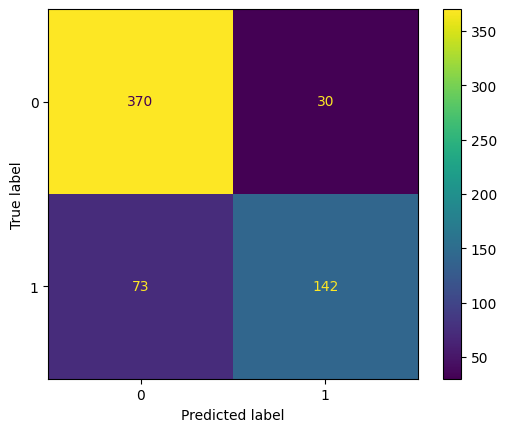

In [12]:
#Plot confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [13]:
#Calculate the accuracy score on training set:
from sklearn.metrics import accuracy_score
accuracy_score(y_train, y_train_pred)

0.832520325203252

### Exercise(s)

1.   Explain the confusion matrix above
2.   What does `accuracy_score` tell us?



### Visualizing the Decision Tree

In [14]:
#Establish class names for the diagnosis
class_Names = ["Negative", "Positive"]
class_Names

['Negative', 'Positive']

In [15]:
#Establish names for the features, that we will used for predicting the diagnosis
feature_Names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", 	"DiabetesPedigreeFunction", "Age"]

In [16]:
#Export decision tree graphics to the "diabetes_tree.dot" file
from sklearn.tree import export_graphviz

export_graphviz(
        tree_clf,
        out_file=str(IMAGES_PATH / "diabetes_tree.dot"),  # path differs in the book
        feature_names=feature_Names,
        class_names=class_Names,
        rounded=True,
        filled=True
    )

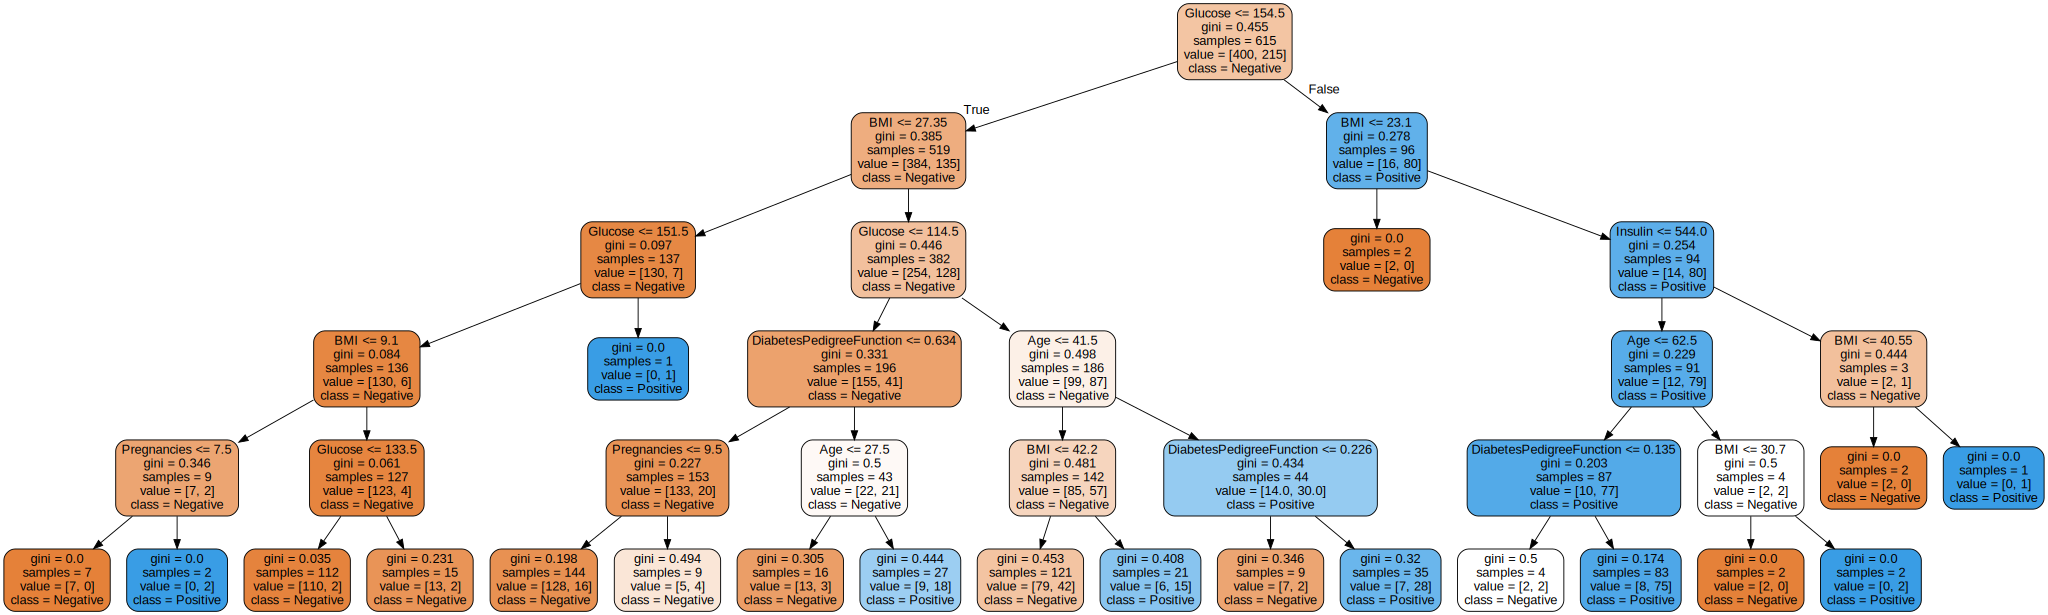

In [17]:
#Load decision tree graphic from the "diabetes_tree.dot" file
from graphviz import Source

Source.from_file(IMAGES_PATH / "diabetes_tree.dot")

In [18]:
#Let the classifier predict diagnosis on test data
y_test_pred=tree_clf.predict(X_test)

In [19]:
#Establish confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, y_test_pred)

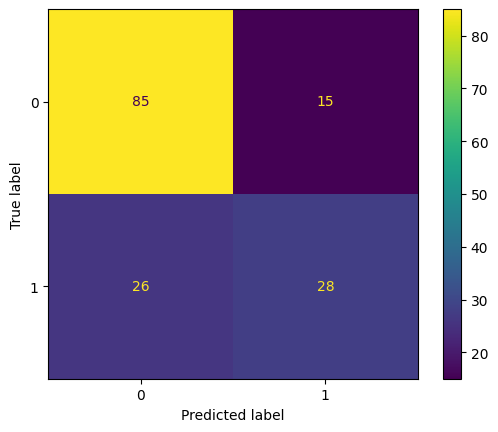

In [20]:
#Plot confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [21]:
#Calculate the accuracy score on test data:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_test_pred)

0.7337662337662337

###Exercise(s)

1.   Compare accuracy scores on training and test data. What does this indicate?
2.   Calculate the recall score by establishing the following piece of code:
```
from sklearn.metrics import recall_score
recall_score(y_test, y_test_pred)
```
Add coding cell(s) acccordingly.
What is the recall score telling you?

3.   Calculate the precison score by establishing the following piece of code:
```
from sklearn.metrics import precision_score
precision_score(y_test, y_test_pred)
```
Add coding cell(s) acccordingly.
What is the precission score telling you?

4.   Try with another classifier algoritm. That is repeating the steps above with this algoritm. Compare performance scores (accuracy, recall & precission).
 Add the needed coding cell(s).
   




In [22]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)

SGDClassifier(random_state=42)

In [23]:
#Let the classifier predict diagnosis on training data
y_train_pred_sgd=sgd_clf.predict(X_train)

In [24]:
#Establish confusion matrix
from sklearn.metrics import confusion_matrix
cm_sgd=confusion_matrix(y_train, y_train_pred_sgd)

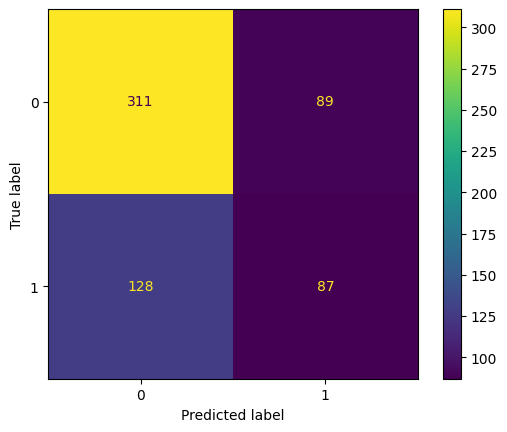

In [25]:
#Plot confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(cm_sgd)
disp.plot()
plt.show()

In [26]:
#Calculate the accuracy score on training set:
from sklearn.metrics import accuracy_score
accuracy_score(y_train, y_train_pred_sgd)

0.6471544715447154